## Batching and Routing Model


In [ ]:
from __future__ import annotations

import datetime
import math
import xml.etree.ElementTree as ET

from dataclasses import dataclass, field
from typing import Callable, Dict, Iterable, List, Sequence, Tuple

import gurobipy as gp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

from gurobipy import GRB
from shapely.geometry import Polygon
from tqdm.auto import tqdm

In [ ]:
# Read polygon from KML + download OSM road network via osmnx

def load_polygon_from_kml(kml_path: str) -> Polygon:
    """
    Read a Polygon from a KML file and return a shapely Polygon (WGS84 lon/lat).
    """
    ns = {"k": "http://www.opengis.net/kml/2.2"}  # KML namespace

    print("STEP 0: start demo")
    tree = ET.parse(kml_path)
    root = tree.getroot()

    coords_elem = root.find(
        ".//k:Polygon/k:outerBoundaryIs/k:LinearRing/k:coordinates",
        ns,
    )
    if coords_elem is None or not coords_elem.text:
        raise ValueError("Could not find Polygon/coordinates node in KML file.")

    text = coords_elem.text.strip()

    coords: List[Coord] = []
    for token in text.split():
        parts = token.split(",")
        lon = float(parts[0])
        lat = float(parts[1])
        coords.append((lon, lat))

    poly = Polygon(coords)
    print("Polygon number of points:", len(coords))
    print("Polygon is valid:", poly.is_valid)
    return poly

In [ ]:
import osmnx as ox
import math

def densify_graph(G, max_segment_length_m=40.0):
    """
    Subdivide every edge in the graph whose 'length' attribute
    is greater than max_segment_length_m.
    Returns a new graph with additional intermediate nodes.
    """
    newG = G.copy()
    next_node_id = max(newG.nodes) + 1  # start for new nodes

    edges_to_remove = []

    for u, v, key, data in G.edges(keys=True, data=True):
        length_m = data.get("length", None)
        if length_m is None or length_m <= max_segment_length_m:
            # nothing to do, keep edge as-is
            continue

        # mark original edge for removal later
        edges_to_remove.append((u, v, key))

        # how many pieces do we want?
        n_parts = math.ceil(length_m / max_segment_length_m)

        # coordinates of endpoints
        x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
        x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]

        # linear interpolation between endpoints
        prev_node = u
        for i in range(1, n_parts):
            t = i / n_parts
            new_x = x1 + (x2 - x1) * t
            new_y = y1 + (y2 - y1) * t

            new_node = next_node_id
            next_node_id += 1

            newG.add_node(new_node, x=new_x, y=new_y)

            # make a new edge from prev_node -> new_node
            # copy attributes except geometry/length, set a shorter length
            new_data = {k: v for k, v in data.items() if k not in ("geometry", "length")}
            new_data["length"] = length_m / n_parts
            newG.add_edge(prev_node, new_node, **new_data)

            prev_node = new_node

        # final edge from last new node -> original v
        new_data = {k: v for k, v in data.items() if k not in ("geometry", "length")}
        new_data["length"] = length_m / n_parts
        newG.add_edge(prev_node, v, **new_data)

    # remove the original long edges
    for u, v, key in edges_to_remove:
        if newG.has_edge(u, v, key):
            newG.remove_edge(u, v, key)

    return newG


def build_osm_graph_from_polygon(poly,
                                 densify: bool = True,
                                 max_segment_length_m: float = 40.0):
    """
    Build a drivable OSM graph inside the given polygon and optionally
    densify edges so no segment is longer than max_segment_length_m.
    """
    # base graph from OSM
    G = ox.graph_from_polygon(poly, network_type="drive", simplify=True)

    # optional densification
    if densify:
        G = densify_graph(G, max_segment_length_m=max_segment_length_m)

    # node_pos mapping
    node_pos = {n: (d["x"], d["y"]) for n, d in G.nodes(data=True)}

    return G, node_pos


In [ ]:
# Distance function: shortest path on the road network (km) with Euclidean fallback if no path exists
# 

def euclidean_distance_km(a: Coord, b: Coord) -> float:
    """Approximate straight-line distance (km), used as fallback when no path exists on the graph."""
    dx = (a[0] - b[0]) * 111.0 * math.cos(math.radians((a[1] + b[1]) / 2))
    dy = (a[1] - b[1]) * 111.0
    return math.hypot(dx, dy)

def make_graph_distance_fn(
    G: nx.Graph,
    node_pos: Dict[int, Coord],
    length_attr: str = "length",
) -> Callable[[Coord, Coord], float]:
    """
    Construct distance_fn(a, b) -> shortest-path distance (km) on the road network.
    If no path exists in the graph, fall back to Euclidean distance.
    """
    # Prepare numpy arrays for nearest-node search
    node_ids = np.array(list(node_pos.keys()))
    xs = np.array([node_pos[i][0] for i in node_ids])  # lon
    ys = np.array([node_pos[i][1] for i in node_ids])  # lat

    coord2node: Dict[Coord, int] = {}

    def nearest_node(coord: Coord) -> int:
        """
        Find the nearest node id by a simple planar approximation.
        """
        lon, lat = coord
        dx = (xs - lon) * 111.0 * np.cos(np.radians((ys + lat) / 2.0))
        dy = (ys - lat) * 111.0
        dist2 = dx * dx + dy * dy
        idx = int(np.argmin(dist2))
        return int(node_ids[idx])

    def get_node_for_coord(c: Coord) -> int:
        if c in coord2node:
            return coord2node[c]
        nid = nearest_node(c)
        coord2node[c] = nid
        return nid

    def distance(a: Coord, b: Coord) -> float:
        """Return distance in km."""
        na = get_node_for_coord(a)
        nb = get_node_for_coord(b)
        try:
            dist_m = nx.shortest_path_length(G, na, nb, weight=length_attr)
            return dist_m / 1000.0
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            # If no path on the road network, fall back to Euclidean distance
            return euclidean_distance_km(a, b)

    return distance


def choose_speed_for_batch(batch: Sequence["Request"]) -> float:
    """
    Choose a reasonable speed (km/h) based on the average hour-of-day of the requests
    in the batch.
    You can adjust these numbers based on your intuition about NYC traffic.
    """
    if not batch:
        return 25.0

    avg_hour = sum(r.hour_of_day for r in batch) / len(batch)

    if 16 <= avg_hour < 19:
        return 20.0
    elif 19 <= avg_hour < 21:
        return 18.0
    elif 21 <= avg_hour < 23:
        return 22.0
    elif avg_hour >= 23 or avg_hour <= 3:
        return 28.0
    else:
        return 24.0


In [ ]:
# Request / VehicleState + batching + Gurobi PDTSP

@dataclass
class Request:
    """A single passenger request: from pickup to dropoff, arriving at arrival_min minutes."""
    req_id: str
    pickup: Coord
    dropoff: Coord
    arrival_min: float        # request arrival time (minutes from simulation start)
    service_date: datetime.date
    num_passengers: int = 1
    hour_of_day: int = 0      # real-world hour of day, used for speed choice


@dataclass
class VehicleState:
    """Vehicle state: location, earliest available time, and the last planned route (node indices)."""
    veh_id: int
    location: Coord
    available_time: float
    planned_route: List[int] = field(default_factory=list)

In [ ]:
def make_time_windows(requests: Sequence[Request], delta_t: float) -> List[List[Request]]:
    """
    Create rolling time windows based on request arrival times.
    window 0 is all requests within 0 <= arrival_min < 5
    window 1 is all requests within 5 <= arrival_min < 10 ... and so forth
    lower bound = inclusive, upper bound = exclusive
    """

    # sort all requests by arrival time (minutes from simulation start)
    requests_sorted = sorted(requests, key=lambda r: r.arrival_min)

    if not requests_sorted:
        return [] # early exist if no requests

    horizon_end = requests_sorted[-1].arrival_min # get last request's arrival time --> this defines how far we need to build windows
   
    batches: List[List[Request]] = []

    # start at t = 0 and use idx as pointer through requests_sorted
    # each request gets consumed exactly 1x (no overlap between windows)
    window_start = 0.0
    idx = 0
    # for each window [window_start, window_end = window_start + delta_t], collect requests that fall in this window
    while window_start <= horizon_end:
        window_end = window_start + delta_t
        window_reqs: List[Request] = [] # collect all requests in this windw
        while idx < len(requests_sorted) and requests_sorted[idx].arrival_min < window_end:
            # as long as next request's arrival is before window_end, attach the request to this window and advance idx
            # when a request is consumed, it can never appear in later windows
            window_reqs.append(requests_sorted[idx])
            idx += 1
        batches.append(window_reqs) # store this window's requests into batches list
        window_start = window_end # then move onto next window


    return batches

    # these are disjoint fixed windows, not overlapping rolling windows
    # each request goes into exactly 1 batch based on its arrival time bucket


In [ ]:
def split_sub_batches(batch: Iterable[Request], capacity: int) -> List[List[Request]]:
    """
    Split a batch into sub-batches so that total number of passengers in each sub-batch <= capacity.
    Example: capacity = 6 -> one vehicle can carry at most 6 passengers in that route.
    """
    sub_batches: List[List[Request]] = []
    current: List[Request] = []
    load = 0  # total passengers in the current sub-batch

    for i, req in enumerate(batch):
        p = req.num_passengers

        # if this request alone exceeds capacity and current is empty, give it its own sub batch
        if p > capacity and not current:
            # Put this as a standalone sub-batch
            sub_batches.append([req])
            continue

        # if adding this request would exceed capacity, close the current sub-batch and start a new one
        if current and load + p > capacity:
            sub_batches.append(current)
            current = []
            load = 0
        current.append(req)
        load += p

    if current:
        sub_batches.append(current)

    return sub_batches


In [9]:
def earliest_pickup_vehicle(
    vehicles: Sequence[VehicleState],
    batch: Sequence[Request],
    distance_fn: Callable[[Coord, Coord], float],
    speed_kmph: float,) -> int:
    """
    Among all vehicles, choose the one that can arrive at any pickup in this batch the earliest.
    """

    if not batch:
        return 0

    best_idx = 0
    best_time = float("inf")
    
    # for each candidate vehicle
    for i, v in enumerate(vehicles):
        # compute distance from its current location to the closest pickup in this batch
        travel_to_batch_km = min(distance_fn(v.location, r.pickup) for r in batch)

        # convert to minutes given speed_kmph
        travel_to_batch_min = travel_to_batch_km * 60.0 / speed_kmph

        # add the vehicle's available_time which is the earliest time this vehicle could start picking up someone in this batch
        start_pickup = v.available_time + travel_to_batch_min

        # get the index with this earliest time
        if start_pickup < best_time:
            best_time = start_pickup
            best_idx = i
            
    # return the index of the vehicle with the smallest such time
    return best_idx

In [10]:
def num_vehicles_at_time(current_time_min, hourly_supply, service_start_hour: int):
    """
    current_time_min: minutes since simulation start (e.g., since 20:00 if service_start_hour=20)
    hourly_supply: dict keyed by absolute hour-of-day (0–23) -> active vehicles
    service_start_hour: absolute hour-of-day when simulation’s t=0 happens
    """
    rel_hour = int(current_time_min // 60)          # how many hours after service start: 0,1,2,3,...
    absolute_hour = (service_start_hour + rel_hour) % 24   # map to 0–23 clock hour --> shifts into wall clock to index hourly_supply
    active = int(hourly_supply.get(absolute_hour,0)) # for debugging only

    return int(hourly_supply.get(absolute_hour, 0))

In [ ]:
def solve_pickup_delivery_batch(
    start_location: Coord,
    start_time: float,
    batch: Sequence[Request],
    capacity: int,
    distance_fn: Callable[[Coord, Coord], float],
    speed_kmph: float,
) -> Dict:
    """
    Solve a single-vehicle pickup-and-delivery TSP (PDTSP) for one batch.

    Inputs:
    - start_location: tuple(lon, lat) --> where the vehicle is physically when it begins serving this batch
        - for the first batch a vehicle serves that night, it's the depot = (-73.9630, 40.8070)
        - for later batches, it's the last dropoff location from that vehicle's previous route
    - start_time: minutes since your service clock origin (e.g. 20:00 if service_starthour = 20)
        - earliest time this vehicle is allowed to start moving for this batch
        - with the "effective_start_time" fix, this is =max(v.available_time, earliest_arrival, batch_start_time_min)
            v_available_time: vehicle not free before this
            earliest_arrival: no reason to drive before first request exists
            batch_start-time_min: bucket start
            this max() is what gets passed in as start_time
    - batch: list of Request objects assigned to this 1 vehicle route aka the set of trips that the vehicle must pick up and drop off in 1 route
        - each Request has at least:
            req_id (str), pickup (Coord), dropoff (Coord),
            arrival_min (request creation time, minutes since service_start_hour),
            service_date (date)
            num_passengers (int)
            hour_of_day (int)
    - capacity: max # of passengers allowed onboard at any point during this route (aka 6)
        - used in the load constraints to ensure we never exceed 6
    - distance_fn: function that takes 2 coords (lon1, lat1) and (lon2, lat2) and returns
        shortest path distance in km on our OSM road graph
        this is what ties our routing model to the real road network
    - speed_kmph: effective cruising speed in km/hr for this batch depending on hour of day
        we chose the values in the function choose_speed_for_batch(batch) based on traffic assumptions

    Returns a dict containing:
      - route_order: list of node indices visited (in order of nodes visited)
          remember 0 is depot, 1..n are pickup nodes, n+1...2n are drop off nodes
      - end_location: final location (lon, lat) of the vehicle after finishing this route
      - finish_time: route end time (minutes)
      - status: Gurobi status code where 2 = OPTIMAL
      - route_travel_time: total travel time (minutes) along the route
      - route_distance_km: total route distance (km)
      - per_request: list of per-request timing statistics such as pred_pickup_time, pred_dropoff_time,
          pred_wait_min, and pred_ride_min
    """
    global FALLBACK_CNT, BAD_STATUS_CNT, BAD_ROUTE_CNT
        # FALLBACK_CNT: how many times we had to use the simple fallback route of:
            # depot --> all pickups --> all dropoffs
        # BAD_STATUS_CNT: how many times Gurobi returned non-optimal statuses
        # BAD_ROUTE_CNT: how many routes were "weird" (wrong length or any precedence violations) even with optimal status from Gurobi

    n = len(batch) # get length of batch

    # if dealing with an empty batch, we immediately return a "do nothing" route where
    # end location = start_location, finish time = start time, status = None
    # this just protects the solver from being called with an empty batch
    if n == 0:
        return {
            "route_order": [],
            "end_location": start_location,
            "finish_time": start_time,
            "status": None,
            "route_travel_time": 0.0,
            "route_distance_km": 0.0,
            "per_request": [],
        }

    # Build node list: depot + all pickups + all dropoffs
    # Node indices: 0 = depot/vehicle start, 1..n = pickup locations for each request in the order they appear in "batch"
    # n+1..2n = corresponding dropoff locations for each request
    nodes: List[Coord] = [start_location] + [r.pickup for r in batch] + [r.dropoff for r in batch]

    # Distance matrix (km) which is a (2n+1) * (2n+1) matrix
          # dist_km[i][j] is the shortest path distance in km from node i to node j
          # on the diagonal (i==j), we set distance equal to 0
    dist_km = [
        [
            distance_fn(nodes[i], nodes[j]) if i != j else 0.0
            for j in range(2 * n + 1)
        ]
        for i in range(2 * n + 1)
    ]

    # Time matrix (minutes) = distance / speed
    # C is the travel time in minutes from node i to j at speed_kmph
    C = [
        [
            dist_km[i][j] * 60.0 / speed_kmph
            for j in range(2 * n + 1)

        ]
        for i in range(2 * n + 1)
    ]

    # GUROBI MODEL - TRAVELING SALESPERSON FOR EACH BATCH AND VEHICLE to determine exact route to take

    m = gp.Model("PDTSP")
    m.Params.OutputFlag = 0 # turns off Gurobi's console logging

    # Decision variables
    x = m.addVars(2 * n + 1, 2 * n + 1, vtype=GRB.BINARY, name="x")
        # x[i,j] = 1 if route goes directly from node i to node j
    T = m.addVars(2 * n + 1, lb=0.0, name="T")
        # T[i] = time variable for arrival time at node i (used for time propagation/ordering in constraints)
    L = m.addVars(2 * n + 1, lb=0.0, ub=capacity, name="L")
        # load (number of passengers onboard) when leaving node i, bounded between 0 and "capacity"=6

    # MTZ ordering variables for subtour elimination on notes 0 to 2n
        # u[i] = the position of node i in the route, domain is [0,2n]
        # creating this variable to prevent subtours and to enforce pick up before drop off
    u = m.addVars(2*n+1, lb=0.0, ub=2*n,name="u")


    # q[j]: change in passenger load when we visit node j
    # q[0] = 0 --> depot doesn't change load
    # for each pickup node 1 to n: q[j] = + num_passengers
    # for each dropoff node n+1..2n: q[j] = - num_passengers
    q = [0.0] \
        + [r.num_passengers for r in batch] \
        + [-r.num_passengers for r in batch]

    # big_M_time is a large enough number for time constraints; not too huge to avoid extreme values.
    big_M_time = 1e6 # large constant used in time constraints to "turn off" constraints when x[i,j] = 0
    big_M_load = capacity + 1 # simialr big-M but for passenger load

    # Objective: minimize total route travel time in minutes
        # sum of all travel times for all arcs where x[i,j]=1
    m.setObjective(
        gp.quicksum(C[i][j] * x[i, j] for i in range(2 * n + 1) for j in range(2 * n + 1)),
        GRB.MINIMIZE,
    )

    # Route structure constraints 

    # Each non-start node has exactly one incoming arc
        # for every node j from 1..2n (all pickups and drop offs), sum of incoming x[i,j] = 1
        # exactly 1 predecessor in the route
    for j in range(1, 2 * n + 1):
        m.addConstr(
            gp.quicksum(x[i, j] for i in range(2 * n + 1) if i != j) == 1,
            name=f"in_{j}",
        )

    # Each non-start node has at most one outgoing arc
        # for each non-depot node i, sum of outgoing x[i,j] <= 1
        # this allows some nodes to be the "end of the route" (no outgoing arc)
        # since we don't force a return to depot
    for i in range(1, 2 * n + 1):
        m.addConstr(
            gp.quicksum(x[i, j] for j in range(2 * n + 1) if j != i) <= 1,
            name=f"out_{i}",
        )

    # For the depot / start node 0: at most one (<=1) outgoing arc, and no incoming arcs (=0)
    m.addConstr(
        gp.quicksum(x[0, j] for j in range(1, 2 * n + 1)) <= 1,
        name="start_out",
    )
    m.addConstr(
        gp.quicksum(x[j, 0] for j in range(2 * n + 1)) == 0,
        name="start_in",
    )

    # No self-loops (prevents things like x[5,5] = 1)
    for i in range(2 * n + 1):
        m.addConstr(x[i, i] == 0, name=f"no_loop_{i}")

    # MTZ subtour elimination constraints on nodes 1 to 2n, depot is 0

    # order variable for depot:
        # set u[0] = 0 for the depot as the 1st position in route
    m.addConstr(u[0]==0.0, name="u_depot")

    # for each non-depot node, clamp u[i] between 1 and 2n --> these are position indices along the route
    # bounds for non-depot nodes --> must appear somewhere in 1 to 2n
    for i in range(1,2*n+1):
        m.addConstr(u[i] >= 1.0, name=f"u_lb_{i}")
        m.addConstr(u[i] <= 2*n, name=f"u_ub_{i}")

    M_mtz = 2*n # big M for MTZ --> enough to cover all positions

    # if x[i,j]==1 and i,j >= 1, then u[j] >= u[i] + 1 : j's position must be strictly after i's position
    # if x[i,j] == 1 then the constraint is relaxed bc RHS becomes very negative
    # this is what prevents subtours --> you can't form a small cycle among pickups/dropoffs w/o eventually violating these order constraints
    for i in range(1,2*n+1):
        for j in range(1,2*n+1):
            if i == j:
                continue
            m.addConstr(u[j] >= u[i] + 1 - M_mtz * (1-x[i,j]),name=f"mtz_{i}_{j}")

    # Time propagation 
    m.addConstr(T[0] == start_time, name="start_time")

    # for every possible arc (i,j), if x[i,j]=1, then travel time to node j must be greataer than travel time to node i
    # if x[i,j]=0, constraint is relaxed by big_M_time
    for i in range(2 * n + 1):
        for j in range(2 * n + 1):
            if i == j:
                continue
            m.addConstr(
                T[j] >= T[i] + C[i][j] - big_M_time * (1 - x[i, j]),
                name=f"time_{i}_{j}",
            )

    # Load propagation + capacity 

    m.addConstr(L[0] == 0.0, name="start_load") # start with passenger load = 0 at depot

    # if you go from i to j then load at node j must be greater than load at node i
        # at pick ups, q[j] > 0 --> load increases
        # at drop offs, q[j] < 0 --> load decreases
    for i in range(2 * n + 1):
        for j in range(2 * n + 1):
            if i == j:
                continue
            m.addConstr(
                L[j] >= L[i] + q[j] - big_M_load * (1 - x[i, j]),
                name=f"load_{i}_{j}",
            )

    # enforce the bounds for passenger load at node i (L[i]) for all nodes
    for i in range(2 * n + 1):
        m.addConstr(L[i] <= capacity, name=f"cap_{i}")
        m.addConstr(L[i] >= 0.0, name=f"nonneg_{i}")

    # ---- Pickup-before-dropoff precedence (using MTZ order u) ----
    for r_idx in range(n):
        pickup_node = 1 + r_idx
        drop_node   = 1 + n + r_idx
        m.addConstr(
            u[drop_node] >= u[pickup_node] + 1,
            name=f"precedence_u_{r_idx}"
        )

    m.optimize()
    status = int(m.Status)

    # function inside solve_pickup_delivery_batch() function

    def build_route_from_solution() -> List[int]:
        """
        Build a route (list of node indices) directly from the x[i,j] solution.
        """
        N = 2 * n + 1
        tol = 1e-4  # numeric tolerance

        successor: Dict[int, int] = {} # maps each node to the next node in the route

        # for each node in route
        for i in range(N):
            # look at all arcs from i with x[i,j] > tol (aka x[i,j] = 1)
            succs = [j for j in range(N) if j != i and x[i, j].X > tol]

            # if multiple successors appear (which theoretically shouldn't happen with perfect constraints), warn and pick the first
            if len(succs) > 1:
                print(f"[WARN] node {i} has multiple successors: {succs}")
                successor[i] = succs[0]
            # if exactly 1 successor, record it
            elif len(succs) == 1:
                successor[i] = succs[0]
            # else: no successor (likely the last node)

        route: List[int] = [0]
        visited = {0}
        current = 0

        # start with node 0 (depot)
        for _ in range(N - 1):
            nxt = successor.get(current) # follow successor[current] through the route
            # stop if either (1) next node is missing which means we reached the end OR
            # (2) next node already has been visited which means we created a cycle. therefore we would need to stop to avoid an infinite loop
            if nxt is None:
                print(f"[WARN] no successor for node {current}, stopping route build.")
                break
            if nxt in visited:
                print(f"[WARN] cycle detected at node {nxt}, route so far: {route}")
                break

            route.append(nxt)
            visited.add(nxt)
            current = nxt
        # return list of visited nodes once we've formed our route
        return route

    # another function inside solve_pickup_delivery_batch() function to check route validity and precedence (more for debugging purposes)
    def route_respects_precedence(route: List[int], n: int) -> bool:
        """
        Check that in the given route, every request's pickup node appears
        before its dropoff node.
        """
        if len(route) != 2 * n + 1: # this is guard in place to see if the route length is not equal to the depot + all pickups + all dropoffs
            return False
        pos = {node: idx for idx, node in enumerate(route)} # pos maps node index to position

        # for each request
        for r_idx in range(n):
            pickup_node = 1 + r_idx
            drop_node   = 1 + n + r_idx
            # if drop off's index appears earlier in the route than the pickup's index --> this is invalid
            if pos.get(drop_node, 999999) < pos.get(pickup_node, -1):
                return False

        # return True only if all precedence conditions are satisfied
        return True


    #  Route selection + debug logging 

    route: List[int] = []          # make sure it's always defined
    successor_route: List[int] = []  # raw route from x

    if status == GRB.OPTIMAL: # if status is optimal from running TSP gurobi model
        successor_route = build_route_from_solution() # build the route based on x[i,j] decision variable output
        route = list(successor_route)

        # failed_length checks if route does not hit all 2n+1 distinct nodes exactly once
        # failed_prec checks if the pickup-dropoff precedence constraint failed
        failed_length = (len(route) != 2 * n + 1) or (len(set(route)) != 2 * n + 1)
        failed_prec   = not route_respects_precedence(route, n)

        # if route is invalid wrt to length or precedence, increment BAD_ROUTE_CNT
        if failed_length or failed_prec:
            BAD_ROUTE_CNT += 1

            # FOR DEBUGGING: for first 5 cases where we have a bad route, print details
            if BAD_ROUTE_CNT <= 5:
                print("\n================ BAD ROUTE EXAMPLE =================")
                print(f"n = {n}, status = {status}")
                print(f"successor-based route: {successor_route}")
                print(f"len(route) = {len(successor_route)}, expected = {2 * n + 1}")
                print(f"unique nodes = {len(set(successor_route))}")
                print(f"failed_length = {failed_length}, failed_prec = {failed_prec}")

                pos = {node: idx for idx, node in enumerate(successor_route)}
                for r_idx in range(n):
                    pickup_node = 1 + r_idx
                    drop_node   = 1 + n + r_idx
                    print(
                        f"req {r_idx}: "
                        f"pickup node {pickup_node} at index {pos.get(pickup_node, 'NA')}, "
                        f"drop node {drop_node} at index {pos.get(drop_node, 'NA')}"
                    )

                print("Arcs with x[i,j] > 0.5:")
                for i in range(2 * n + 1):
                    for j in range(2 * n + 1):
                        if x[i, j].X > 0.5:
                            print(f"  x[{i},{j}] = {x[i,j].X:.1f}")

                print("u[i] (MTZ order) and T[i] (times):")
                for i in range(2 * n + 1):
                    print(f"  node {i}: u={u[i].X:.2f}, T={T[i].X:.2f}")
                print("====================================================\n")

    else:
        # if no optimal solution from gurobi model, we clear the route and success_route to trigger the use of "fallback" route
        route = []
        successor_route = []

    # If truly unusable (no optimal solution OR route length way off), fall back route
    if status != GRB.OPTIMAL or len(route) != 2 * n + 1:
        FALLBACK_CNT += 1
        if status != GRB.OPTIMAL:
            BAD_STATUS_CNT += 1
        else:
            BAD_ROUTE_CNT += 1

        # for debugging only
        if BAD_ROUTE_CNT <= 5:
            print(
                f"[DEBUG] using simple fallback route: n={n}, "
                f"len(route)={len(route)}, status={status}, SolCount={m.SolCount}"
            )

        # Set route to simple deterministic fallback: depot -> all pickups -> all dropoffs
        # aka visit all pickups in their original order than all dropoffs
        route = [0] + [1 + i for i in range(n)] + [1 + n + i for i in range(n)]

    # -- Simulate times along the chosen route ---

    # Accumulate node visit times along the route
    delay_pickup = {
        1 + r_idx: float(np.random.uniform(0.0, 2.0))  # node indices 1..n are pickups
        for r_idx in range(n)
      }

    node_times = [0.0] * (2 * n + 1) # this will store the time we reach node i
    node_times[0] = start_time # set depot time equal to start_time

    for k in range(len(route) - 1): # for each edge in the chosen route
        # time at j = time at i + travel time from i to j
        # note: this assumes no additional waiting time at nodes --> this is pure drive time
        i = route[k]
        j = route[k + 1]

        travel_time = C[i][j]

        # Service/delay time at the ARRIVAL node j
        delay_time = 0.0
        if 1 <= j <= n:  # pickup nodes only
            delay_time = delay_pickup[j]

        node_times[j] = node_times[i] + travel_time + delay_time


       # node_times[j] = node_times[i] + C[i][j] <-- original version


    finish_time = node_times[route[-1]] # time we reach last node the route (end of route time)

    # Compute total route distance / time
    total_dist = 0.0
    total_time = 0.0
    for k in range(len(route) - 1):
        i = route[k]
        j = route[k + 1]
        total_dist += dist_km[i][j]
        total_time += C[i][j]
        # this sums up the total distance and travel time over all consecutive legs of "route"

    # Per-request time statistics: pickup/dropoff/wait/ride times

        # this uses route order from Gurobi. post-adjust timing such that no one is picked up before they
        # request ride. ride duration from solved route is preserved

    per_request = []
    # per_request will collect one dict per request in this batch

    # r_idx is the index of the request in batch, req is the corresponding Request object
    for r_idx, req in enumerate(batch):

        pickup_node = 1 + r_idx # pick up node
        drop_node   = 1 + n + r_idx # drop off node
                # ex) if r_idx = 0, pick up node = 1, drop off node = 1 + n
                # ex) if r_idx = 3, pick up node = 4, drop off node = 1 + n + 3

        # times from raw route
        pickup_raw = node_times[pickup_node]
            # node_times was defined earlier in this function
            # node_times[i] = time (minutes) at which the vehicle reaches node i assuming it leaves node 0 at start_time and immediately drives (no extra waiting at nodes)
           # IMPORTANT ASSUMPTION: DRIVER DOES NOT WAIT FOR PASSENGER. ASSUME PASSENGER IS THERE WHEN DRIVER ARRIVES
           # pickup_raw = time when vehicle reaches request's pick up
        drop_raw  = node_times[drop_node] # time when vehicile reaches request's dropoff

        # 1) Enforce "cannot pick up before request arrives"
        pickup_time = max(pickup_raw, req.arrival_min)
            # req.arrival_min = request creation time (in min) since nightly service start of vehicle (minutes since 8pm on service_date which is when door to door service starts each night)
            # if raw route would go to pickup before request exists (pickup_raw < arrival_min) that's unrealistic
            # this max() function means: if vehicle would arrive early, it just waits until request appears
                # if it naturally arrives later than arrival_min use that later time
                # aka we never pick someone up before they hit "request ride"

        # 2) Preserve ride duration implied by the route
        ride_duration_raw = drop_raw - pickup_raw
            # travel time (min) between pick up and drop from the route

        drop_time = pickup_time + ride_duration_raw
            # if you delay pick up by some amount, you also delay drop off by same amount --> this keeps in-vehicle time consistent with path length

        # 3) Now compute wait & ride time
        wait_time = pickup_time - req.arrival_min      # now guaranteed >= 0
            # wait_time = how long the rider waits between requesting and being picked up
        ride_time = drop_time - pickup_time
            # ride_time = how long they're in the vehicle
            # since drop_time = pickup_time + ride_duration_raw, ride_time = ride_duration_raw

        per_request.append(
            {
                "req_id": req.req_id,
                "arrival_min": req.arrival_min,
                "pred_pickup_time": pickup_time,
                "pred_dropoff_time": drop_time,
                "pred_wait_min": wait_time,
                "pred_ride_min": ride_time,
            }
        )
        # pred_pickup_time: adjusted pick up time respecting arrival_min
        # pred_dropoff_time: adjusted drop off time preserving ride duration
        # pred_wait_min = final predicted wait
        # pred_ride_min = final predicted ride time

        # these end up in df_pred and is merged with real data in the output csv file

    end_node = route[-1] # last node visited in route

    # recompute finish_time because if many pickups are delayed to arrival_min, their drop_time could be later than finish_time from the raw path
    # now the vehicle becomes available only after the last adjusted dropoff
    finish_time = max(
        node_times[route[-1]],
        max(r["pred_dropoff_time"] for r in per_request)
    )

    return {
        "route_order": route,
        "end_location": nodes[end_node],
        "finish_time": finish_time,
        "status": status,
        "route_travel_time": total_time,
        "route_distance_km": total_dist,
        "per_request": per_request,
    }
    # route_travel_time and route_distance_km = still based on pure travel (no waiting) which is fine if we view them as "driving only cost
    # end_location: used to update vehicle's location for the next batch


In [ ]:
def run_dispatch_policy(
    requests: Sequence[Request],
    vehicles: Sequence[VehicleState],
    delta_t: float,
    capacity: int,
    distance_fn: Callable[[Coord, Coord], float],
    hourly_supply,
    service_start_hour: int
) -> Dict:
    """
    Run the full dispatch policy:
      - rolling time-window batching
      - capacity-based sub-batching
      - dynamic vehicle assignment.
    Returns:
      {
        "vehicles": [...],
        "batches": [...],            # route-level info
        "per_request_stats": [...]   # per-request timing info
      }
    """
    print(f"STEP 3: make time windows for {delta_t}")
    batches = make_time_windows(requests, delta_t) # calls function make_time_windows on this day's requests

    all_batches: List[List[Request]] = []
    # for each time window split into capacity feasible sub batches by calling function split_sub_batches
    for b in batches:
        all_batches.extend(split_sub_batches(b, capacity))
    # all_batches is now a list of sub-batches -> each to be assigned to a vehicle
    print(f"STEP 4: total sub-batches = {len(all_batches)}")

    solved_batches = []
    all_per_request: List[Dict] = []

    # Iterate over all sub-batches with tqdm progress bar

    for b_idx, batch in enumerate(tqdm(all_batches, desc="Solving batches")):
        # b_idx is index into all_batches (0,1,2...) --> identifying the sub-batch in this day
        speed_kmph = choose_speed_for_batch(batch) # chosen based on hour of day of requests in batch
        # empty batch is skipped but it shouldn't happen
        if len(batch) == 0:
            continue

    # Time logic: how many vehicles are allowed this hour
        if batch:
            earliest_arrival = min(req.arrival_min for req in batch) # first request arrival in this sub batch
            batch_start_time_min = math.floor(earliest_arrival / delta_t) * delta_t
                # floor to nearest delta_t bucket (if earliest is 22.7 and delta_t = 5 then you get 20)
                # used only to decide how many vehicles are on duty (= active_limit) and for the "dont start before earliest arrival" constraint we add
        else:
            batch_start_time_min = 0.0  # empty batch (shouldn’t really happen)

        # below looks up how many vehicles should be on duty at that time in the night (8pm-3am)
        active_limit = num_vehicles_at_time(
            batch_start_time_min,
            hourly_supply,
            service_start_hour = service_start_hour
        )

        # don't drop the batch if supply hour = 0; slide its start time forward until some supply exists 
        if active_limit == 0: # which shouldn't happen but just in case as safe guard
            temp_time = batch_start_time_min
            while num_vehicles_at_time(temp_time, hourly_supply) == 0 and temp_time < 24*60:
                temp_time += delta_t   # move forward one batching window (in increments of delta_t until some supply appears)

            new_limit = num_vehicles_at_time(temp_time, hourly_supply) # then re evaluate what the # of vehicles should be on the road at this hour

            if new_limit == 0: # if still no supply, log and skip
                # Safe guard here if there is literally no supply anywhere in the day
                print(f"[DEBUG] batch {b_idx} found no supply all day; still skipping")
                continue
            else:
                batch_start_time_min = temp_time
                active_limit = new_limit

        # ensure every batch still gets sent to "solve_pickup_delivery_batch" --> none are silently dropped

        # choose vehicle only among active vehicles 
        if b_idx < active_limit:
            # first few batches: just give each its own vehicle, but
            # only up to the number allowed this hour
            veh_idx = b_idx
        else:
            # for later batches, pick the earliest pickup vehicle
            # but only among the first active_limit vehicles
            veh_idx = earliest_pickup_vehicle(
                vehicles[:active_limit],  # only “on-duty” vehicles
                batch,
                distance_fn,
                speed_kmph,
            )

        v = vehicles[veh_idx] # vehicles in an input  --> vehicle assigned for this particular batch

        # do not start the route before requests actually exist 
        # earliest_arrival is already computed above for this batch
        # batch_start_time_min is the time you've aligned to the supply plan

        effective_start_time = max(v.available_time, earliest_arrival, batch_start_time_min + delta_t)

        result = solve_pickup_delivery_batch(
            start_location=v.location,
            start_time=effective_start_time,   
            batch=batch,
            capacity=capacity,
            distance_fn=distance_fn,
            speed_kmph=speed_kmph,
        )

        # update chosen vehicle state to reflect ending location and time

        v.location = result["end_location"]
        v.available_time = result["finish_time"]
        v.planned_route = result["route_order"]

        # Attach vehicle id, batch index, and speed_kmph to each per-request record
        for r in result["per_request"]:
            r["vehicle"] = v.veh_id
            r["batch_idx"] = b_idx
            r["speed_kmph"] = speed_kmph
            all_per_request.append(r)

        solved_batches.append(
            {
                "vehicle": v.veh_id,
                "batch_idx": b_idx,
                "speed_kmph": speed_kmph,
                **result,
            }
        )

    print("STEP 7: dispatch finished")

    return {
        "vehicles": vehicles,
        "batches": solved_batches,
        "per_request_stats": all_per_request,
    }


In [ ]:
# Demo: KML + road network + CSV + comparison with real data

import osmnx as ox

def example_usage_with_graph(
    delta_t:float, 
    scenario_name: str,
    supply_df: pd.DataFrame | None = None) -> dict:
    
    global FALLBACK_CNT, BAD_STATUS_CNT, BAD_ROUTE_CNT

    print(f"start demo for {delta_t} and {scenario_name}")

    # Read KML polygon (service area polygon) from KML file that's the Columbia area
    poly = load_polygon_from_kml("shuttle.kml")

    # Build OSM road network (10 m)
    G, node_pos = build_osm_graph_from_polygon(poly)

        # queries OSm for all roads inside that polygon
        # builds directed graph G (nodes = intersections, edges = road segments)
        # builds node_pos (dict mapping node id) --> (lon, lat) or (x,y) for plotting and distance calcs

    # Build distance_fn
        # wraps graph into callable distance_fn (origin_coord, dest_coord) --> distance_in_km 
        # internally snaps origin/dest to nearest nodes, do shortest path on G using edge attribute "length" and returns the length
    distance_fn = make_graph_distance_fn(
        G,
        node_pos,
        length_attr="length",
    )

    # Choose a depot
    # Instead of picking an arbitrary node, we set the depot near Columbia campus (hard coding shuttle depot)
    # all vehicles start at this point at time 0 in our simulation
    depot_coord = (-73.9630, 40.8070)
    print("Depot coord (lon, lat):", depot_coord)

    # Read requests from CSV
    csv_path = "Ride Requests_2025-11-11-part-2.csv" 
    df = pd.read_csv(csv_path) # every row = ride request

    # Ensures that these columns are actual datatime64 objects so that we can extract stuff like .dt.hour, subtract/add them together etc
    # if any are NaT, later calculations will produce NaNs
    df["Request Creation Time"] = pd.to_datetime(df["Request Creation Time"])
    df["Actual Pickup Time"] = pd.to_datetime(df["Actual Pickup Time"])
    df["Actual Dropoff Time"] = pd.to_datetime(df["Actual Dropoff Time"])

    # Define service window 
    service_start_hour = 20 # 8pm start for door to door 

    # Assign service_date per request
    #  If request created >= 6pm → belongs to that calendar day
    #  If request created < 6pm  → belongs to previous day (overnight shift)
    # ex) if someone requests at 1am on Oct 2 --> operationally we treat this as part of the Oct 1 shuttle service
    df["service_date"] = np.where(
        df["Request Creation Time"].dt.hour >= service_start_hour,
        df["Request Creation Time"].dt.date,
        (df["Request Creation Time"] - pd.Timedelta(days=1)).dt.date
    )

    # Extract hour-of-day (integer hour 0-23) from request creation time used for filtering and speed selection
    df["hour_of_day"] = df["Request Creation Time"].dt.hour

    # Keep only requests occurring between 8pm and 3am
    mask_time = (df["hour_of_day"] >= service_start_hour) | (df["hour_of_day"] < 3)

    # Keep week of interest -- for debugging purposes, only running the 1st week of October
    mask_oct = (
        (df["service_date"] >= date(2025, 10, 1))
        & (df["service_date"] <= date(2025, 10, 14))
    )

    df = df[mask_time & mask_oct].copy() # apply both masks to the dataframe
    print(len(df), "Completed requests in Oct 1–7 operational window") # this prints how many rows "survived"

    # at this point, df = all requests (regardless of status) that were created btwn 8pm-3am, and belong to oct XX service dates

    # create time stamp for each row --> service_start_dt = 8pm of assigned service_date
    # ex) if service_date = 2025-10-03, then service_start_dt = 2025-10-03 20:00:00
    service_start_dt = (
        pd.to_datetime(df["service_date"]) + pd.Timedelta(hours=service_start_hour)
    )
    #ompute arrival_min relative to service clock = how many minutes after 8pm that this request was created
    df["arrival_min"] = (
        df["Request Creation Time"] - service_start_dt
    ).dt.total_seconds() / 60.0

    # Assign req_id
    df = df.reset_index(drop=True) 
    df["req_id"] = df.index.to_series().apply(lambda i: f"req_{i}")
        # create unique req_id string like "req_0" or "req_1" --> key that will follow through simulation and subsequent merges

    # Build Request objects
    requests: List[Request] = []
    # loop through every row and constraint domain object "Request" with the following
    for _, row in df.iterrows():
        req = Request(
        req_id=row["req_id"],
        pickup=(row["Origin Lng"], row["Origin Lat"]),
        dropoff=(row["Destination Lng"], row["Destination Lat"]),
        arrival_min=row["arrival_min"],          # minutes since 8pm on service_date
        service_date=row["service_date"],        # already a date object
        num_passengers=int(row["Number of Passengers"]), # passenger count
        hour_of_day=int(row["Request Creation Time"].hour), # 0-23
    )

        requests.append(req) # after looping through, this is a clean list of Request objects
        
    # Load October 2025 supply plan 
    if supply_df is None:
        supply_df = pd.read_excel("CUL October 2025 Supply Plan.xlsx", sheet_name=0)
    else:
        # work on a copy so we don't mutate caller's dataframe
        supply_df = supply_df.copy() 
        
    supply_df["Date"] = pd.to_datetime(supply_df["Date"])

    def build_hourly_supply_for_row(row):
        """Given one row of supply_df (specific date), construct and return a dict: hour -> # of vehicles.
        Here we are just only filling out 16-23 and 0-2. everything else stays 0 (off shift)
        """
        
        hourly_supply = {h: 0 for h in range(24)}
        hourly_supply[16] = row['4p-5p']   # 16:00–17:00
        hourly_supply[17] = row['5p-6p']
        hourly_supply[18] = row['6p-7p']
        hourly_supply[19] = row['7p-8p']
        hourly_supply[20] = row['8p-9p']
        hourly_supply[21] = row['9p-10p']
        hourly_supply[22] = row['10p-11p']
        hourly_supply[23] = row['11p-12a']
        hourly_supply[0]  = row['12a-1a']
        hourly_supply[1]  = row['1a-2a']
        hourly_supply[2]  = row['2a-3a']
        return hourly_supply

    # Build dict: {date -> {hour: supply}} 
    supply_by_date = {
        row["Date"].date(): build_hourly_supply_for_row(row)
        for _, row in supply_df.iterrows()
    }

    # Run dispatch separately for EACH service_date (each date in october) 
    all_batches = []
    all_per_request_stats = []

    # Which unique service dates actually appear in the request data
    request_dates = sorted(df["service_date"].unique())

    # loop through the days 
    for day in request_dates:
        if day not in supply_by_date:
            print(f"Skipping {day}: no supply plan in Excel.")
            continue
            # skip if there is no row in the supply sheet for that date 

        # Filter requests for this specific date
        day_requests = [r for r in requests if r.service_date == day]
        if not day_requests:
            print(f"Skipping {day}: no completed requests.")
            continue

        hourly_supply = supply_by_date[day]      # for this date, fetch the hour --> vehicles dict
        MAX_VEHICLES = max(hourly_supply.values()) # maximum # of vehicles across all hours 
        print(f"\n=== Running dispatch for {day} with MAX_VEHICLES={MAX_VEHICLES} ===")

        # based on the value of MAX_VEHICLES, that's how many VehicleState objects we create
        # some may be idle/off-shift depending on time
        
        # all start at depot at time 0 minutes since 8pm
        vehicles = [
            VehicleState(
                veh_id=i,
                location=depot_coord,
                available_time=0.0
            )
            for i in range(MAX_VEHICLES)
        ]

        # Run dispatch for this day only 
        result = run_dispatch_policy(
            requests=day_requests,
            vehicles=vehicles,
            delta_t=delta_t,    # time window length in minutes
            capacity=6,     # max total passengers per route
            distance_fn=distance_fn,
            hourly_supply=hourly_supply,
            service_start_hour = service_start_hour
        )
            # result has batches (route level info per solved batch) and per_request_stats (one row per served request)
       
        # Collect batch-level results
        df_batches_day = pd.DataFrame(result["batches"])
        df_batches_day["date"] = day
        all_batches.append(df_batches_day)

        # Collect request-level results
        df_per_req_day = pd.DataFrame(result["per_request_stats"])
        df_per_req_day["date"] = day
        all_per_request_stats.append(df_per_req_day)

    # Combine all days together 
    if all_batches:
        df_batches = pd.concat(all_batches, ignore_index=True)
    else:
        df_batches = pd.DataFrame()

    if all_per_request_stats:
        df_pred = pd.concat(all_per_request_stats, ignore_index=True)
    else:
        df_pred = pd.DataFrame()
    # df_batches: one row per batch (route)
    # df_pred: one row per request that go simulated 
    
    # All request IDs in the filtered raw data for this run
    all_req_ids = set(df["req_id"])
    # All request IDs that actually got per-request stats from the simulator
    served_req_ids = set(df_pred["req_id"]) if not df_pred.empty else set()

    missing_ids = sorted(all_req_ids - served_req_ids)
        
    print("\nStatus counts (all days):")
    if "status" in df_batches.columns:
        print(df_batches["status"].value_counts(dropna=False))
    print("\nNumber of fallback routes:", FALLBACK_CNT)
    print("Bad statuses:", BAD_STATUS_CNT)
    print("Bad routes:", BAD_ROUTE_CNT)
    
    # for each combination of service_date, vehicle, batch_idx --> get list of req_ids served in that batch
    reqs_per_route = (
        df_pred.groupby(["date","vehicle", "batch_idx"])['req_id']
        .apply(list)
        .reset_index()
        .rename(columns={'req_id':'served_requests'})
    )
    # joint route-level info with list of requests per route
    df_batches_with_requests = df_batches.merge(reqs_per_route, on=["date","vehicle","batch_idx"],how="left")

    
    #  Request-level statistics: merge with original df
    route_steps = []

    # form route for each (vehicle, batch_idx) pair with the actual seq of requests being picked up and dropped off
    for _, row in df_batches_with_requests.iterrows():
        route = row["route_order"]          # list of node indices, e.g. [0, 1, 5, 10, ...]
        reqs  = row["served_requests"]      # list of req_ids, e.g. ['req_0', ..., 'req_5']
        n = len(reqs)
        
        for step_idx, node in enumerate(route):
            if node == 0:
                stop_type = "depot"
                req_id = None
            elif 1 <= node <= n:
                stop_type = "pickup"
                req_id = reqs[node - 1]
            elif n + 1 <= node <= 2 * n:
                stop_type = "dropoff"
                req_id = reqs[node - (n + 1)]
            else:
                stop_type = "unknown"
                req_id = None

            route_steps.append({
                "date": row["date"],
                "vehicle": row["vehicle"],
                "batch_idx": row["batch_idx"],
                "step_idx": step_idx,   # 0,1,2,... in the order visited
                "node": node,
                "stop_type": stop_type, # depot / pickup / dropoff
                "req_id": req_id,
            })

    route_steps_df = pd.DataFrame(route_steps)
    route_steps_df.to_csv(f"{delta_t}route_stop_sequence_october_ver2.csv", index=False)
    
    # merge simulated per request stats with raw datas 
    if not df_pred.empty:
        merged = df.merge(df_pred, on="req_id", how="inner", suffixes=("_org","_pred"))
        # merged now has original columns plus predicted ones for only served requests (inner join)
        # should see: rows in merged == rows in df_pred

        # True actual ride time - derived from real data 
        merged["actual_ride_min"] = (
            (merged["Actual Dropoff Time"] - merged["Actual Pickup Time"])
            .dt.total_seconds() / 60.0
        )

        # True actual waiting time: from request creation to actual pickup (derived from real data)
        merged["actual_wait_min"] = (
            (merged["Actual Pickup Time"] - merged["Request Creation Time"])
            .dt.total_seconds() / 60.0
        )
    
        # Error stats
        merged["ride_error"] = merged["pred_ride_min"] - merged["actual_ride_min"]

        # Summary outputs for the sensitivity analysis
        metrics = {
            "scenario": scenario_name,
            "delta_t": delta_t,
            "n_requests_raw": len(df),
            "n_requests_simulated": len(df_pred),
            "n_requests_merged": len(merged),
            "avg_pred_ride": merged["pred_ride_min"].mean(),
            "avg_act_ride": merged["actual_ride_min"].mean(),
            "avg_pred_wait": merged["pred_wait_min"].mean(),
            "avg_act_wait": merged["actual_wait_min"].mean(),
            "mean_ride_error": merged["ride_error"].mean(),
            "mae_ride_error": merged["ride_error"].abs().mean(),
            "fallback_routes": FALLBACK_CNT,
            "bad_statuses": BAD_STATUS_CNT,
            "bad_routes": BAD_ROUTE_CNT,
        }
        
        merged["raw_wait"] = merged["pred_pickup_time"] - merged["arrival_min_org"]

        print("\nPredicted wait summary (minutes):")
        print("mean:", merged["pred_wait_min"].mean())
        print("min / 25% / 50% / 75% / 90% / max of pred_wait_min:")
        print(merged["pred_wait_min"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))

        print("\nRaw (pre-clamp) wait summary (minutes):")
        print("min / 25% / 50% / 75% / 90% /max of raw_wait:")
        print(merged["raw_wait"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))

        # Save for further analysis or plotting
        merged.to_csv(f"{scenario_name}_{delta_t}request_level_comparison_october_ver2.csv", index=False)
        df_batches_with_requests.to_csv(f"{scenario_name}_{delta_t}batch_level_routes_october_ver2.csv", index=False)
        print(f"\nSaved: {scenario_name}_{delta_t}request_level_comparison_october_ver2.csv, {scenario_name}_batch_level_routes_october_ver2.csv", "route_stop_sequence_october_ver2.csv")
        return metrics

    else:
        print("\nNo prediction results to merge/save.")
        return {
            "delta_t": delta_t, 
            "n_requests": 0,
            "avg_pred_ride": None,
            "avg_act_ride": None,
            "avg_pred_wait": None,
            "avg_act_wait": None,
            "mean_ride_error": None,
            "mae_ride_error": None, 
            "fallback_routes": FALLBACK_CNT, 
            "bad_statuses": BAD_STATUS_CNT, 
            "bad_routes": BAD_ROUTE_CNT,
        }


## Sensitivity Analysis - Vehicle Supply Level

In [ ]:
def run_supply_sensitivity(delta_t: float) -> pd.DataFrame:
    """
    Run the dispatch simulation for three supply scenarios stored
    as separate sheets in the same Excel file:

      - sheet 0: baseline supply plan
      - sheet 1: 20% lower supply plan
      - sheet 2: 20% higher supply plan
      - sheet 3: 40% lower supply plan

    Returns a DataFrame with one row of summary metrics per scenario.
    Also writes a CSV summary to disk.
    """
    
    excel_path = "CUL October 2025 Supply Plan.xlsx"

    # (name, sheet index)
    scenarios = [
      ("Baseline", 0),
        ("Low Supply - 20%", 1),
        ("High Supply - 20%", 2)
    ]

    results = []

    for scenario_name, sheet_idx in scenarios:
        print(f"\n\n=== Running scenario: {scenario_name} (sheet {sheet_idx}) ===")

        # Read the appropriate sheet
        supply_df = pd.read_excel(excel_path, sheet_name=sheet_idx)

        # Reset global counters so each scenario starts “fresh”
        global FALLBACK_CNT, BAD_STATUS_CNT, BAD_ROUTE_CNT
        FALLBACK_CNT = 0
        BAD_STATUS_CNT = 0
        BAD_ROUTE_CNT = 0

        metrics = example_usage_with_graph(
            delta_t=delta_t,
            supply_df=supply_df,
            scenario_name=scenario_name,
        )

        results.append(metrics)

    summary_df = pd.DataFrame(results)
    summary_df.to_csv(f"{scenario_name}_summary_dt_oct1to14{int(delta_t)}.csv", index=False)

    print("\nSaved summary to:",
          f"{scenario_name}_summary_dt_oct1to14{int(delta_t)}.csv")

    return summary_df


In [39]:
summary = run_supply_sensitivity(delta_t=5.0)
summary



=== Running scenario: Baseline (sheet 0) ===
start demo for 5.0 and Baseline
STEP 0: start demo
Polygon number of points: 25
Polygon is valid: True
Depot coord (lon, lat): (-73.963, 40.807)
10363 Completed requests in Oct 1–7 operational window

=== Running dispatch for 2025-10-01 with MAX_VEHICLES=17 ===
STEP 3: make time windows for 5.0
STEP 4: total sub-batches = 189


Solving batches:   0%|          | 0/189 [00:00<?, ?it/s]

STEP 7: dispatch finished

=== Running dispatch for 2025-10-02 with MAX_VEHICLES=17 ===
STEP 3: make time windows for 5.0
STEP 4: total sub-batches = 203


Solving batches:   0%|          | 0/203 [00:00<?, ?it/s]

STEP 7: dispatch finished

=== Running dispatch for 2025-10-03 with MAX_VEHICLES=16 ===
STEP 3: make time windows for 5.0
STEP 4: total sub-batches = 219


...

Solving batches:   0%|          | 0/180 [00:00<?, ?it/s]

STEP 7: dispatch finished

=== Running dispatch for 2025-10-14 with MAX_VEHICLES=20 ===
STEP 3: make time windows for 5.0
STEP 4: total sub-batches = 179


Solving batches:   0%|          | 0/179 [00:00<?, ?it/s]

STEP 7: dispatch finished

Status counts (all days):
status
2    2667
Name: count, dtype: int64

Number of fallback routes: 0
Bad statuses: 0
Bad routes: 0

Predicted wait summary (minutes):
mean: 12.547414912796041
min / 25% / 50% / 75% / 90% / max of pred_wait_min:
0.00     1.100635
0.25     7.698901
0.50    11.423154
0.75    16.395313
0.90    21.411016
1.00    42.611840
Name: pred_wait_min, dtype: float64

Raw (pre-clamp) wait summary (minutes):
min / 25% / 50% / 75% / 90% /max of raw_wait:
0.00     1.100635
0.25     7.698901
0.50    11.423154
0.75    16.395313
0.90    21.411016
1.00    42.611840
Name: raw_wait, dtype: float64

Saved: High Supply - 20%_5.0request_level_comparison_october_ver2.csv, High Supply - 20%_batch_level_routes_october_ver2.csv route_stop_sequence_october_ver2.csv

Saved summary to: High Supply - 20%_summary_dt_oct1to145.csv


,scenario,delta_t,n_requests_raw,n_requests_simulated,n_requests_merged,avg_pred_ride,avg_act_ride,avg_pred_wait,avg_act_wait,mean_ride_error,mae_ride_error,fallback_routes,bad_statuses,bad_routes
0,Baseline,5.0,10363,10363,10363,7.971996,8.948452,14.487573,25.128514,-0.738993,4.812848,0,0,0
1,Low Supply - 20%,5.0,10363,10363,10363,7.950689,8.948452,31.250042,25.128514,-0.801087,4.777218,0,0,0
2,High Supply - 20%,5.0,10363,10363,10363,7.944516,8.948452,12.547415,25.128514,-0.778774,4.815058,0,0,0


In [53]:
scenarios = [
    ("Baseline", 0),
    ("Low Supply - 20%", 1),
    ("High Supply - 20%", 2)]

for name,idx in scenarios:
    
    merged = pd.read_csv(f"{name}_5.0request_level_comparison_october_ver2.csv")
    print(f"============scenario = {name} =============")
    print("\nPredicted wait summary (minutes):")
    print("mean:", merged["pred_wait_min"].mean())
    print("min / 25% / 50% / 75% / 90% / max of pred_wait_min:")
    print(merged["pred_wait_min"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))

    print("\nRaw (pre-clamp) wait summary (minutes):")
    print("min / 25% / 50% / 75% / 90% /max of raw_wait:")
    print(merged["raw_wait"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))

    print("avg_pred_ride:",merged["pred_ride_min"].mean())
    print("avg_act_ride:", merged["actual_ride_min"].mean())
    print("avg_pred_wait:", merged["pred_wait_min"].mean())
    print("avg_act_wait:", merged["actual_wait_min"].mean())
    
    print("Pred ride min distirbution")
    print("min / 25% / 50% / 75% / 90% / max of pred_ride_min:")
    print(merged["pred_ride_min"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))
 

============scenario = Baseline =============

Predicted wait summary (minutes):
mean: 14.487572949081736
min / 25% / 50% / 75% / 90% / max of pred_wait_min:
0.00     1.204497
0.25     8.435256
0.50    12.947295
0.75    19.126307
0.90    25.366550
1.00    52.008312
Name: pred_wait_min, dtype: float64

Raw (pre-clamp) wait summary (minutes):
min / 25% / 50% / 75% / 90% /max of raw_wait:
0.00     1.204497
0.25     8.435256
0.50    12.947295
0.75    19.126307
0.90    25.366550
1.00    52.008312
Name: raw_wait, dtype: float64
avg_pred_ride: 7.9719960093463715
avg_act_ride: 8.948451882845188
avg_pred_wait: 14.487572949081736
avg_act_wait: 25.1285140562249
Pred ride min distirbution
min / 25% / 50% / 75% / 90% / max of pred_ride_min:
0.00     0.000000
0.25     3.704611
0.50     6.515509
0.75    10.993934
0.90    15.871270
1.00    34.263807
Name: pred_ride_min, dtype: float64
============scenario = Low Supply - 20% =============

Predicted wait summary (minutes):
mean: 31.250041534882296
min 

In [ ]:
# mean + 95% CI 
from typing import Tuple
import math

def mean_ci(series: pd.Series, alpha: float = 0.05) -> Tuple[float, float, float]:
    """
    Return (mean, lower_95, upper_95) for a 1D numeric Series.
    Uses normal approximation with sample std.
    """
    s = series.dropna().astype(float)
    n = len(s)
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    mean = s.mean()
    std = s.std(ddof=1)
    z = 1.96  # for 95% CI
    half_width = z * std / math.sqrt(n)
    return mean, mean - half_width, mean + half_width


In [52]:
# conf intervals based on vehicle supply level changes sensitivity analysis results
scenarios = [
    ("Baseline", 0),
    ("Low Supply - 20%", 1),
    ("High Supply - 20%", 2)]

for name,idx in scenarios:
    
    merged = pd.read_csv(f"{name}_5.0request_level_comparison_october_ver2.csv")
    print(f"============scenario = {name} =============")
    
    mean_pred_wait, lo_pred_wait, hi_pred_wait = mean_ci(merged["pred_wait_min"])
    mean_act_wait,  lo_act_wait,  hi_act_wait  = mean_ci(merged["actual_wait_min"])

    mean_pred_ride, lo_pred_ride, hi_pred_ride = mean_ci(merged["pred_ride_min"])
    mean_act_ride,  lo_act_ride,  hi_act_ride  = mean_ci(merged["actual_ride_min"])

    print("\n95% CI (minutes):")
    print(f"Predicted wait: mean={mean_pred_wait:.2f}, 95% CI for {name} [{lo_pred_wait:.2f}, {hi_pred_wait:.2f}]")
     #   print(f"Actual    wait: mean={mean_act_wait:.2f}, 95% CI for delta_t = {delta_t} [{lo_act_wait:.2f}, {hi_act_wait:.2f}]")
    print(f"Predicted ride: mean={mean_pred_ride:.2f}, 95% CI for delta_t = {name} [{lo_pred_ride:.2f}, {hi_pred_ride:.2f}]")
     #   print(f"Actual    ride: mean={mean_act_ride:.2f}, 95% CI for delta_t = {delta_t}[{lo_act_ride:.2f}, {hi_act_ride:.2f}]")


============scenario = Baseline =============

95% CI (minutes):
Predicted wait: mean=14.49, 95% CI for Baseline [14.34, 14.64]
Predicted ride: mean=7.97, 95% CI for delta_t = Baseline [7.87, 8.08]
============scenario = Low Supply - 20% =============

95% CI (minutes):
Predicted wait: mean=31.25, 95% CI for Low Supply - 20% [30.92, 31.58]
Predicted ride: mean=7.95, 95% CI for delta_t = Low Supply - 20% [7.85, 8.06]
============scenario = High Supply - 20% =============

95% CI (minutes):
Predicted wait: mean=12.55, 95% CI for High Supply - 20% [12.43, 12.67]
Predicted ride: mean=7.94, 95% CI for delta_t = High Supply - 20% [7.84, 8.05]


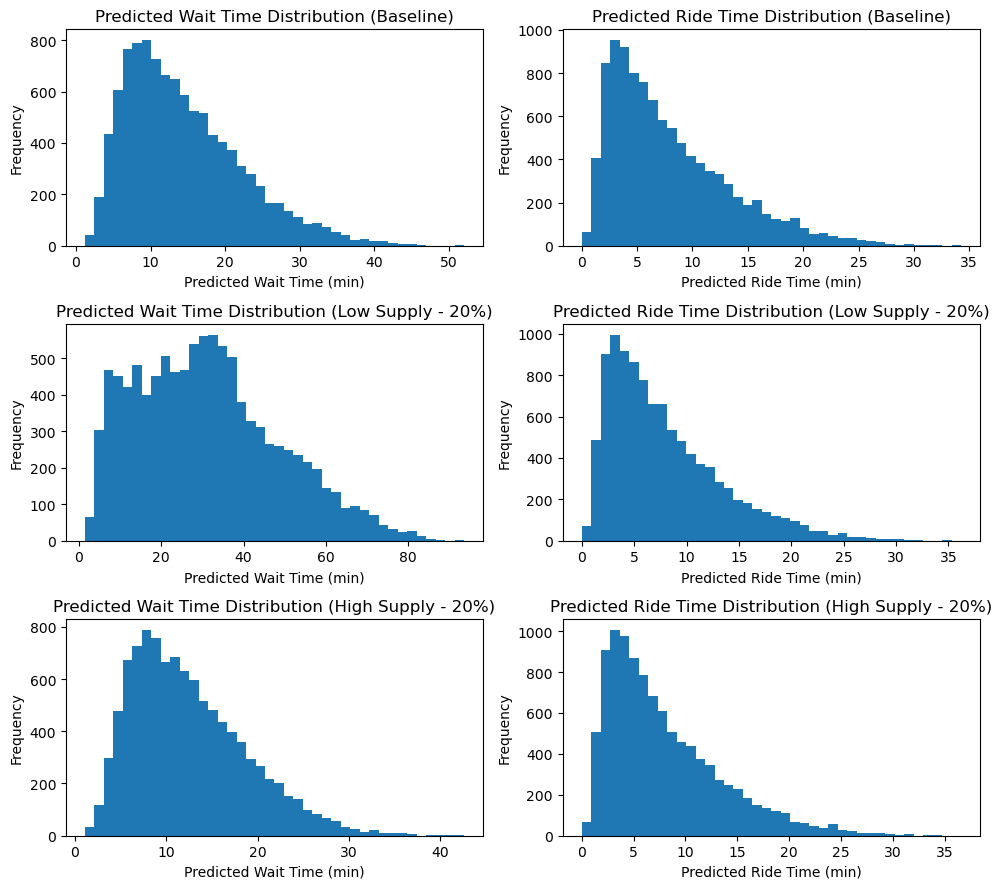

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

scenarios = [
    ("Baseline", 0),
    ("Low Supply - 20%", 1),
    ("High Supply - 20%", 2)]


fig, axes = plt.subplots(len(scenarios), 2,
                         figsize=(10, 3 * len(scenarios)))

for name,idx in scenarios:
    merged = pd.read_csv(f"{name}_5.0request_level_comparison_october_ver2.csv")

    #  Predicted WAIT distribution 
    ax_w = axes[idx, 0]
    ax_w.hist(merged["pred_wait_min"], bins=40)
    ax_w.set_title(f"Predicted Wait Time Distribution ({name})")
    ax_w.set_ylabel("Frequency")
    ax_w.set_xlabel("Predicted Wait Time (min)")

    #  Predicted RIDE distribution 
    ax_r = axes[idx, 1]
    ax_r.hist(merged["pred_ride_min"], bins=40)
    ax_r.set_title(f"Predicted Ride Time Distribution ({name})")
    ax_r.set_ylabel("Frequency")
    ax_r.set_xlabel("Predicted Ride Time (min)")


plt.tight_layout()
plt.show()


## Sensitivity Analysis - Delta_t

In [ ]:
def run_delta_t_sensitivity():
  
    delta_t_values = [2.0, 5.0, 8.0, 10.0, 15.0]

    excel_path = "CUL October 2025 Supply Plan.xlsx"

    # (name, sheet index)
    scenarios = [("Baseline", 0)]

    results = []

    for scenario_name, sheet_idx in scenarios:
        for dt in delta_t_values: 
            print(f"\n\n=== Running scenario: {scenario_name} (sheet {sheet_idx}) ===")
            print("\n" + "="*60)
            print(f"Running simulation with delta_t = {dt} minutes")
            print("="*60)
            # Read the appropriate sheet
            supply_df = pd.read_excel(excel_path, sheet_name=sheet_idx)

            # Reset global counters so each scenario starts “fresh”
            global FALLBACK_CNT, BAD_STATUS_CNT, BAD_ROUTE_CNT
            FALLBACK_CNT = 0
            BAD_STATUS_CNT = 0
            BAD_ROUTE_CNT = 0

            metrics = example_usage_with_graph(
                delta_t=dt,
                supply_df=supply_df,
                scenario_name=scenario_name,
            )
            
            results.append(metrics)

    summary_df = pd.DataFrame(results)
    summary_df.to_csv(f"delta_tsensitivity_oct1-14summary.csv", index=False)

    print("\nSaved summary to:",
          f"delta_t_sensitivity_oct-14summary.csv")

    return summary_df

In [ ]:
if __name__ == "__main__":
    run_delta_t_sensitivity()



=== Running scenario: Baseline (sheet 0) ===

Running simulation with delta_t = 2.0 minutes
start demo for 2.0 and Baseline
STEP 0: start demo
Polygon number of points: 25
Polygon is valid: True
Depot coord (lon, lat): (-73.963, 40.807)
10363 Completed requests in Oct 1–7 operational window

=== Running dispatch for 2025-10-01 with MAX_VEHICLES=17 ===
STEP 3: make time windows for 2.0
STEP 4: total sub-batches = 241


Solving batches:   0%|          | 0/241 [00:00<?, ?it/s]

STEP 7: dispatch finished

=== Running dispatch for 2025-10-02 with MAX_VEHICLES=17 ===
STEP 3: make time windows for 2.0
STEP 4: total sub-batches = 258


Solving batches:   0%|          | 0/258 [00:00<?, ?it/s]

STEP 7: dispatch finished

=== Running dispatch for 2025-10-03 with MAX_VEHICLES=16 ===
STEP 3: make time windows for 2.0
STEP 4: total sub-batches = 273


...

Solving batches:   0%|          | 0/154 [00:00<?, ?it/s]

STEP 7: dispatch finished

=== Running dispatch for 2025-10-14 with MAX_VEHICLES=17 ===
STEP 3: make time windows for 15.0
STEP 4: total sub-batches = 152


Solving batches:   0%|          | 0/152 [00:00<?, ?it/s]

STEP 7: dispatch finished

Status counts (all days):
status
2    2350
Name: count, dtype: int64

Number of fallback routes: 0
Bad statuses: 0
Bad routes: 0

Predicted wait summary (minutes):
mean: 20.140346415599105
min / 25% / 50% / 75% / 90% / max of pred_wait_min:
0.00     1.041809
0.25    14.080669
0.50    19.296804
0.75    25.606627
0.90    31.606790
1.00    53.551600
Name: pred_wait_min, dtype: float64

Raw (pre-clamp) wait summary (minutes):
min / 25% / 50% / 75% / 90% /max of raw_wait:
0.00     1.041809
0.25    14.080669
0.50    19.296804
0.75    25.606627
0.90    31.606790
1.00    53.551600
Name: raw_wait, dtype: float64

Saved: Baseline_15.0request_level_comparison_october_ver2.csv, Baseline_batch_level_routes_october_ver2.csv route_stop_sequence_october_ver2.csv


NameError: name 'delta_t' is not defined

In [54]:
delta_t_values = [2.0, 5.0, 8.0, 10.0, 15.0]
for dt in delta_t_values:
    
    merged = pd.read_csv(f"Baseline_{dt}request_level_comparison_october_ver2.csv")
    print(f"============delta_t={dt}=============")
    print("\nPredicted wait summary (minutes):")
    print("mean:", merged["pred_wait_min"].mean())
    print("min / 25% / 50% / 75% / 90% / max of pred_wait_min:")
    print(merged["pred_wait_min"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))

    print("\nRaw (pre-clamp) wait summary (minutes):")
    print("min / 25% / 50% / 75% / 90% /max of raw_wait:")
    print(merged["raw_wait"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))

    print("avg_pred_ride:",merged["pred_ride_min"].mean())
    print("avg_act_ride:", merged["actual_ride_min"].mean())
    print("avg_pred_wait:", merged["pred_wait_min"].mean())
    print("avg_act_wait:", merged["actual_wait_min"].mean())
    
    print("Pred ride min distribution")
    print("min / 25% / 50% / 75% / 90% / max of pred_ride_min:")
    print(merged["pred_ride_min"].quantile([0, 0.25, 0.5, 0.75, 0.9, 1]))
    

============delta_t=2.0=============

Predicted wait summary (minutes):
mean: 12.889904725679827
min / 25% / 50% / 75% / 90% / max of pred_wait_min:
0.00     1.109062
0.25     6.536366
0.50    11.024790
0.75    17.659666
0.90    24.574572
1.00    51.043431
Name: pred_wait_min, dtype: float64

Raw (pre-clamp) wait summary (minutes):
min / 25% / 50% / 75% / 90% /max of raw_wait:
0.00     1.109062
0.25     6.536366
0.50    11.024790
0.75    17.659666
0.90    24.574572
1.00    51.043431
Name: raw_wait, dtype: float64
avg_pred_ride: 7.29475850660161
avg_act_ride: 8.948451882845188
avg_pred_wait: 12.889904725679827
avg_act_wait: 25.1285140562249
Pred ride min distribution
min / 25% / 50% / 75% / 90% / max of pred_ride_min:
0.00     0.000000
0.25     3.316601
0.50     5.739616
0.75     9.892098
0.90    14.820057
1.00    32.551437
Name: pred_ride_min, dtype: float64
============delta_t=5.0=============

Predicted wait summary (minutes):
mean: 14.487572949081736
min / 25% / 50% / 75% / 90% / ma

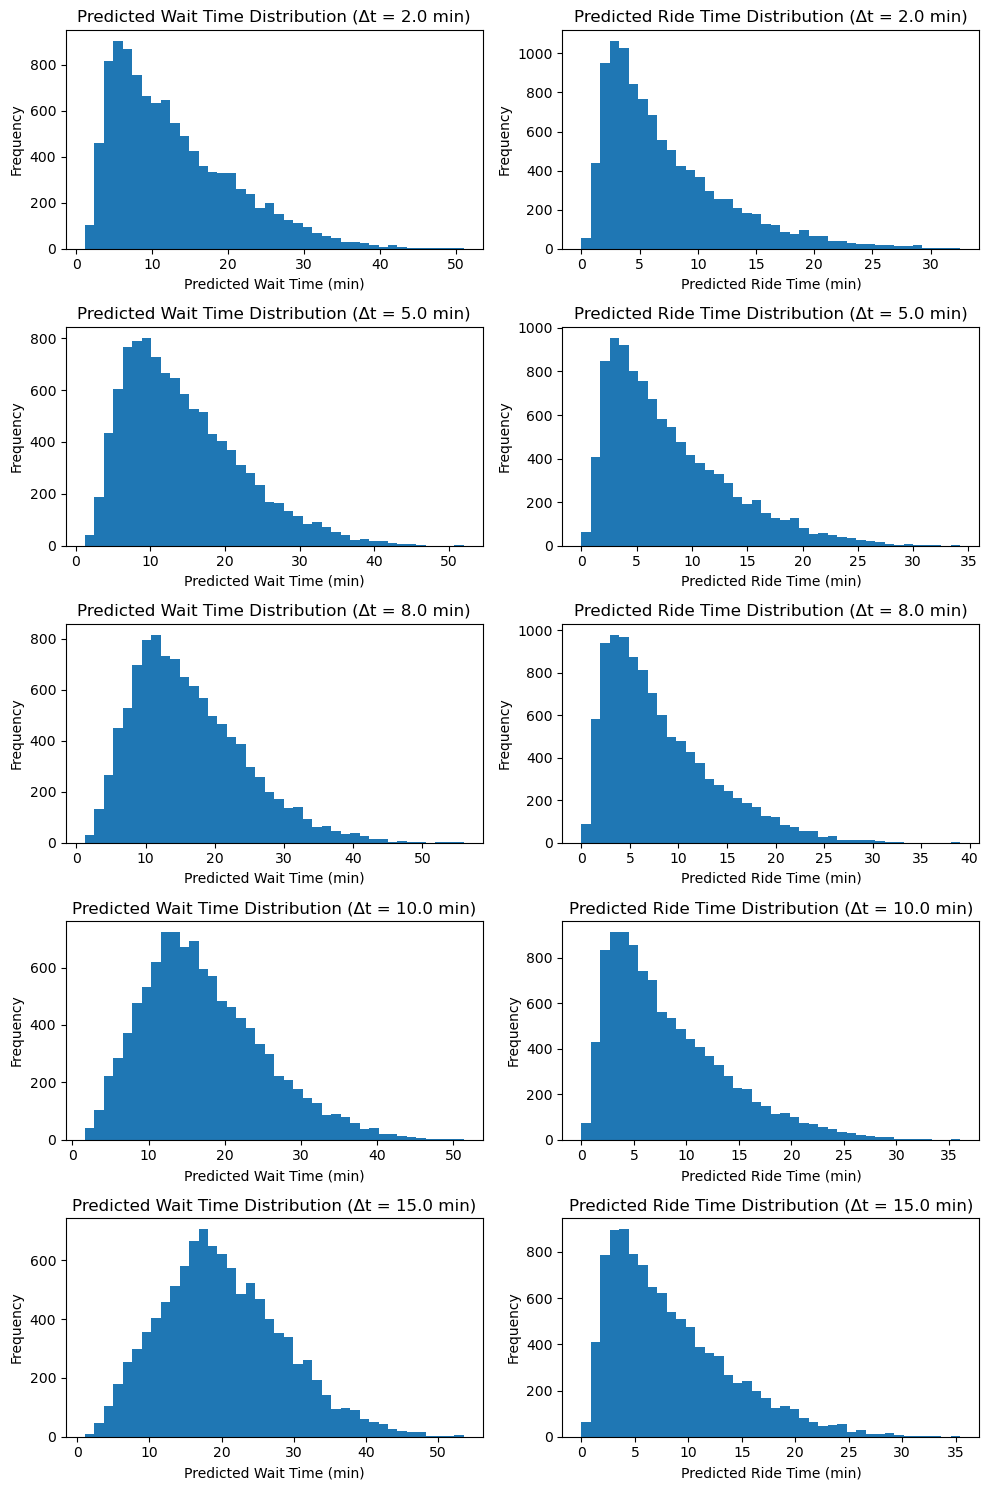

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

delta_t_values = [2.0, 5.0, 8.0, 10.0, 15.0]

fig, axes = plt.subplots(len(delta_t_values), 2,
                         figsize=(10, 3 * len(delta_t_values)))

for i, dt in enumerate(delta_t_values):
    merged = pd.read_csv(f"Baseline_{dt}request_level_comparison_october_ver2.csv")

    # -------- Predicted WAIT distribution --------
    ax_w = axes[i, 0]
    ax_w.hist(merged["pred_wait_min"], bins=40)
    ax_w.set_title(f"Predicted Wait Time Distribution (Δt = {dt} min)")
    ax_w.set_ylabel("Frequency")
    ax_w.set_xlabel("Predicted Wait Time (min)")

    # -------- Predicted RIDE distribution --------
    ax_r = axes[i, 1]
    ax_r.hist(merged["pred_ride_min"], bins=40)
    ax_r.set_title(f"Predicted Ride Time Distribution (Δt = {dt} min)")
    ax_r.set_ylabel("Frequency")
    ax_r.set_xlabel("Predicted Ride Time (min)")

# Shared x-labels
# axes[-1, 0].set_xlabel("Wait Time (minutes)")
# axes[-1, 1].set_xlabel("Ride Rime (minutes)")

plt.tight_layout()
plt.show()
